# Baseline RNN: Genre-Conditioned Story Generation

A simple recurrent baseline before training the Transformer. This notebook trains a **genre-conditioned** word-level language model and tracks metrics you will compare against later.

**Model options** (set `MODEL_TYPE` below):
- `"lstm"` — LSTM text generator (default)
- `"gru"` — small GRU model

**Tracked metrics:**
- Training & validation **loss**
- **Perplexity** (exp of cross-entropy loss)
- **Sample generations** during training

**Prerequisites:** Run `2. Preprocessing.ipynb` so `../data/train.csv`, `val.csv`, and `test.csv` exist.

## 1. Setup

In [1]:
import json
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Project root and shared utilities
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from utils import (
    count_parameters,
    format_time,
    get_device,
    print_model_summary,
    save_checkpoint,
    save_config,
    set_seed,
)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "ggplot")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = PROJECT_ROOT / "data"
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "baseline_rnn"
CHECKPOINT_DIR = EXPERIMENT_DIR / "checkpoints"
LOG_DIR = EXPERIMENT_DIR / "logs"

for d in (CHECKPOINT_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

device = get_device()
print(f"Project root: {PROJECT_ROOT}")

Using Apple Silicon MPS
Project root: /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator


## 2. Configuration

Switch `MODEL_TYPE` to `"gru"` to train the small GRU baseline instead of LSTM.

In [2]:
# --- Model choice: "lstm" or "gru" ---
MODEL_TYPE = "lstm"  # change to "gru" for the GRU baseline

CONFIG = {
    "model_type": MODEL_TYPE,
    "seed": 42,
    "seq_len": 128,
    "batch_size": 32,
    "embed_dim": 256,
    "hidden_dim": 512,
    "num_layers": 2,
    "dropout": 0.3,
    "min_word_freq": 2,
    "max_vocab_size": 15000,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 15,
    "clip_grad": 1.0,
    "sample_every": 3,
    "max_gen_words": 80,
    "temperature": 0.9,
}

set_seed(CONFIG["seed"])
print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  model_type: lstm
  seed: 42
  seq_len: 128
  batch_size: 32
  embed_dim: 256
  hidden_dim: 512
  num_layers: 2
  dropout: 0.3
  min_word_freq: 2
  max_vocab_size: 15000
  learning_rate: 0.001
  weight_decay: 1e-05
  epochs: 15
  clip_grad: 1.0
  sample_every: 3
  max_gen_words: 80
  temperature: 0.9


## 3. Load Preprocessed Splits

In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Genres (train): {train_df['genre'].nunique()}")
train_df.head(2)

Train: 699 | Val: 150 | Test: 151
Genres (train): 99


,genre,story,title,word_count
0,Space Opera,"In the distant reaches of the galaxy, a starsh...",The Starfarers Dilemma,155
1,Psychological Horror,"Part 1: The Beginning In a small, serene town ...",The Haunting of Windridge Manor,1000


## 4. Vocabulary & Genre Mapping

Word-level tokenizer built from the training set. Special tokens: `<pad>`, `<unk>`, `<bos>`, `<eos>`.

In [4]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]


def tokenize(text: str) -> list[str]:
    return str(text).lower().split()


def build_vocab(texts, min_freq=2, max_vocab_size=15000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
    for word, freq in counter.most_common():
        if word in vocab:
            continue
        if freq < min_freq:
            break
        if len(vocab) >= max_vocab_size:
            break
        vocab[word] = len(vocab)

    inv_vocab = {idx: tok for tok, idx in vocab.items()}
    return vocab, inv_vocab


vocab, inv_vocab = build_vocab(
    train_df["story"],
    min_freq=CONFIG["min_word_freq"],
    max_vocab_size=CONFIG["max_vocab_size"],
)

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]
BOS_IDX = vocab[BOS_TOKEN]
EOS_IDX = vocab[EOS_TOKEN]

# Genre → integer id (conditioning signal)
genres = sorted(train_df["genre"].unique())
genre_to_idx = {g: i for i, g in enumerate(genres)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}

print(f"Vocabulary size: {len(vocab):,}")
print(f"Number of genres: {len(genre_to_idx)}")

Vocabulary size: 15,000
Number of genres: 99


In [5]:
def encode_words(words: list[str]) -> list[int]:
    return [vocab.get(w, UNK_IDX) for w in words]


def decode_ids(ids: list[int]) -> str:
    tokens = []
    for i in ids:
        tok = inv_vocab.get(i, UNK_TOKEN)
        if tok in (PAD_TOKEN, BOS_TOKEN):
            continue
        if tok == EOS_TOKEN:
            break
        tokens.append(tok)
    return " ".join(tokens)


def encode_story(story: str, max_len: int) -> list[int]:
    tokens = [BOS_IDX] + encode_words(tokenize(story)) + [EOS_IDX]
    if len(tokens) > max_len:
        tokens = tokens[: max_len - 1] + [EOS_IDX]
    return tokens

## 5. Dataset & DataLoaders

Each sample is a fixed-length chunk for next-token prediction. Inputs are tokens `[:-1]`, targets are `tokens[1:]`.

In [6]:
class GenreStoryDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, seq_len: int):
        self.samples = []
        for _, row in dataframe.iterrows():
            genre_id = genre_to_idx[row["genre"]]
            token_ids = encode_story(row["story"], max_len=seq_len + 1)
            if len(token_ids) < 4:
                continue
            self.samples.append((genre_id, token_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre_id, token_ids = self.samples[idx]
        x = torch.tensor(token_ids[:-1], dtype=torch.long)
        y = torch.tensor(token_ids[1:], dtype=torch.long)
        return genre_id, x, y


def collate_batch(batch):
    genre_ids, xs, ys = zip(*batch)
    genre_ids = torch.tensor(genre_ids, dtype=torch.long)
    xs = pad_sequence(xs, batch_first=True, padding_value=PAD_IDX)
    ys = pad_sequence(ys, batch_first=True, padding_value=PAD_IDX)
    return genre_ids, xs, ys


train_dataset = GenreStoryDataset(train_df, CONFIG["seq_len"])
val_dataset = GenreStoryDataset(val_df, CONFIG["seq_len"])
test_dataset = GenreStoryDataset(test_df, CONFIG["seq_len"])

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_batch,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_batch,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_batch,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 22 | Val batches: 5


## 6. Genre-Conditioned RNN Model

Genre embedding is concatenated with token embeddings at every timestep, then passed through stacked LSTM or GRU layers.

In [7]:
class GenreRNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_genres: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        rnn_type: str = "lstm",
        pad_idx: int = 0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.genre_embedding = nn.Embedding(num_genres, embed_dim)
        self.dropout = nn.Dropout(dropout)

        rnn_cls = nn.LSTM if rnn_type.lower() == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            input_size=embed_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, genre_ids, input_ids, hidden=None):
        token_emb = self.token_embedding(input_ids)
        genre_emb = self.genre_embedding(genre_ids).unsqueeze(1).expand(-1, input_ids.size(1), -1)
        x = torch.cat([token_emb, genre_emb], dim=-1)
        x = self.dropout(x)
        output, hidden = self.rnn(x, hidden)
        logits = self.output(output)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
        if isinstance(self.rnn, nn.LSTM):
            c = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
            return (h, c)
        return h


model = GenreRNN(
    vocab_size=len(vocab),
    num_genres=len(genre_to_idx),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    rnn_type=CONFIG["model_type"],
    pad_idx=PAD_IDX,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

print_model_summary(model)


MODEL SUMMARY
Total trainable parameters: 15,762,840

Model architecture:
GenreRNN(
  (token_embedding): Embedding(15000, 256, padding_idx=0)
  (genre_embedding): Embedding(99, 256)
  (dropout): Dropout(p=0.3, inplace=False)
  (rnn): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.3)
  (output): Linear(in_features=512, out_features=15000, bias=True)
)



## 7. Training Utilities

- **Loss**: mean cross-entropy over non-padding tokens
- **Perplexity**: `exp(loss)`
- **Generation**: autoregressive sampling with temperature

In [11]:
def compute_loss(logits, targets):
    vocab_size = logits.size(-1)
    return criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))


def perplexity_from_loss(loss: float) -> float:
    return float(np.exp(min(loss, 20)))  # cap for numerical stability


@torch.no_grad()
def evaluate(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for genre_ids, inputs, targets in data_loader:
        genre_ids = genre_ids.to(device)
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits, _ = model(genre_ids, inputs)
        loss = compute_loss(logits, targets)

        mask = targets != PAD_IDX
        n_tokens = mask.sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, perplexity_from_loss(avg_loss)


def train_one_epoch(model, data_loader, epoch):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    pbar = tqdm(data_loader, desc=f"Epoch {epoch} [train]")
    for genre_ids, inputs, targets in pbar:
        genre_ids = genre_ids.to(device)
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits, _ = model(genre_ids, inputs)
        loss = compute_loss(logits, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["clip_grad"])
        optimizer.step()

        mask = targets != PAD_IDX
        n_tokens = mask.sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, perplexity_from_loss(avg_loss)


@torch.no_grad()
def generate_story(
    model,
    genre: str,
    prompt: str = "",
    max_words: int = 80,
    temperature: float = 0.9,
):
    model.eval()
    genre_id = torch.tensor([genre_to_idx[genre]], device=device)

    if prompt.strip():
        seed = [BOS_IDX] + encode_words(tokenize(prompt))
    else:
        seed = [BOS_IDX]

    generated = seed.copy()
    hidden = model.init_hidden(1, device)

    for _ in range(max_words):
        # Shape (batch=1, seq_len=1) — must match training inputs
        inp = torch.tensor([[generated[-1]]], device=device)
        logits, hidden = model(genre_id, inp, hidden)
        logits = logits[:, -1, :] / max(temperature, 1e-6)
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == EOS_IDX:
            break
        generated.append(next_id)

    return decode_ids(generated)


def print_sample_generations(model, epoch, genres_to_try=None):
    if genres_to_try is None:
        genres_to_try = [
            "Science Fiction",
            "Romance",
            "Horror",
            "Mystery",
        ]
        genres_to_try = [g for g in genres_to_try if g in genre_to_idx]

    print(f"\n{'=' * 70}")
    print(f"Sample generations — epoch {epoch}")
    print(f"{'=' * 70}")

    prompts = ["", "once upon a time", "the detective"]

    for genre in genres_to_try:
        for prompt in prompts[:2]:
            text = generate_story(
                model,
                genre=genre,
                prompt=prompt,
                max_words=CONFIG["max_gen_words"],
                temperature=CONFIG["temperature"],
            )
            label = f"[{genre}]" + (f" prompt='{prompt}'" if prompt else "")
            print(f"\n{label}\n{text[:400]}{'...' if len(text) > 400 else ''}")

## 8. Training Loop

In [12]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_ppl": [],
    "val_ppl": [],
    "epoch_time": [],
}

best_val_loss = float("inf")
start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()

    train_loss, train_ppl = train_one_epoch(model, train_loader, epoch)
    val_loss, val_ppl = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["epoch_time"].append(time.time() - epoch_start)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} (ppl {train_ppl:.1f}) | "
        f"val loss {val_loss:.4f} (ppl {val_ppl:.1f}) | "
        f"time {format_time(history['epoch_time'][-1])}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model,
            optimizer,
            epoch,
            val_loss,
            CHECKPOINT_DIR / f"best_{CONFIG['model_type']}.pt",
            config=CONFIG,
            vocab_size=len(vocab),
        )

    if epoch == 1 or epoch % CONFIG["sample_every"] == 0 or epoch == CONFIG["epochs"]:
        print_sample_generations(model, epoch)

print(f"\nTotal training time: {format_time(time.time() - start_time)}")
print(f"Best validation loss: {best_val_loss:.4f} (ppl {perplexity_from_loss(best_val_loss):.1f})")

Epoch 1 [train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 01 | train loss 6.5251 (ppl 682.0) | val loss 6.4217 (ppl 615.0) | time 5s
Checkpoint saved to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/checkpoints/best_lstm.pt

Sample generations — epoch 1

[Science Fiction]
seraphina she dr. his bustling soviet the the with a in intricate quiet year of form relying <unk> this the by formed sharing to the city's our of a no them the a <unk> her in was there computer at and secret. the the colors, that a suddenly, a the evenings comfortably oblivious of in a on and of the he in <unk> warmth, day, of and the two hero, <unk> to leaving had were as a life days

[Science Fiction] prompt='once upon a time'
once upon a time president. upon the with <unk> was with waiting guardians on had and glenwood, her, chest, lived was inside he a the protector was beings. a of his our if and a determined as by and to human dense <unk> equipped who the the been stood was venture determin

Epoch 2 [train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 02 | train loss 6.4853 (ppl 655.5) | val loss 6.3835 (ppl 592.0) | time 5s
Checkpoint saved to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/checkpoints/best_lstm.pt


Epoch 3 [train]:   0%|          | 0/22 [00:00<?, ?it/s]

...

Epoch 13 | train loss 5.2322 (ppl 187.2) | val loss 5.3919 (ppl 219.6) | time 4s
Checkpoint saved to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/checkpoints/best_lstm.pt


Epoch 14 [train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 14 | train loss 5.1440 (ppl 171.4) | val loss 5.3348 (ppl 207.4) | time 4s
Checkpoint saved to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/checkpoints/best_lstm.pt


Epoch 15 [train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 15 | train loss 5.0552 (ppl 156.8) | val loss 5.2901 (ppl 198.4) | time 4s
Checkpoint saved to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/checkpoints/best_lstm.pt

Sample generations — epoch 15

[Science Fiction]
in the heart of the distant there the or hills of most law. the <unk> was a reclusive to dreams. and the had it as the lives. and the dramatic of the distant of the <unk> she had had <unk> <unk> the story terrain. and the townsfolk and a hidden <unk> that the was always of a

[Science Fiction] prompt='once upon a time'
once upon a time alike quiet in the <unk> the order of the younger lit and the <unk> of the town, about and the shadowy star it was an forever tree he ancient for

[Horror]
in the picturesque a street of the village giant a place and the race was a secret family that was not had a passion to the starship the <unk> at hidden they library. his hospital to you honor, to this their for

## 9. Training & Validation Curves

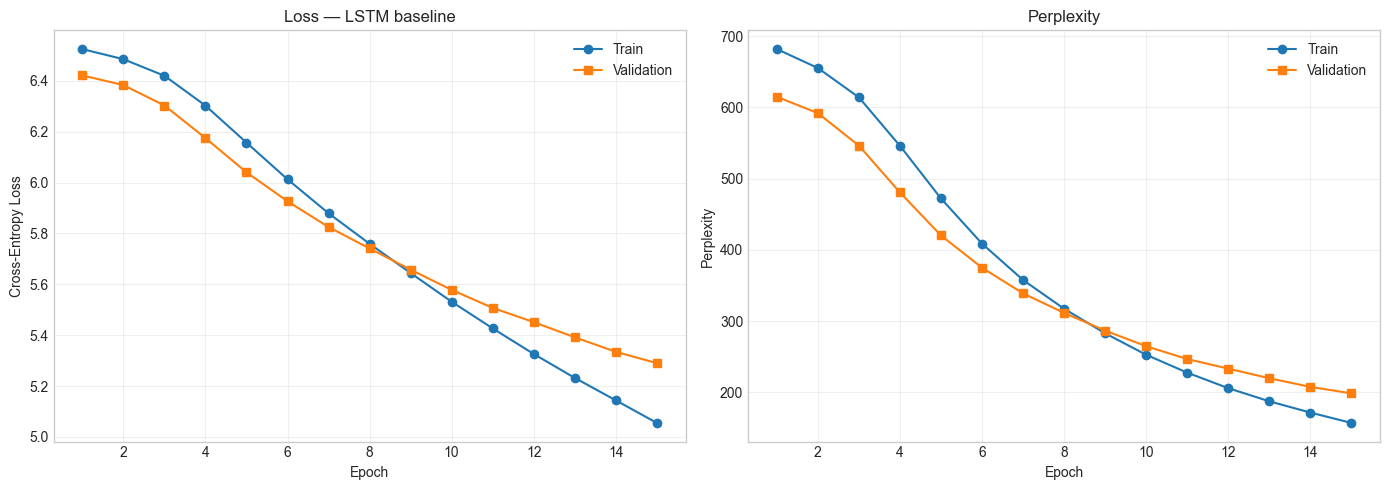

In [13]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history["val_loss"], marker="s", label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title(f"Loss — {CONFIG['model_type'].upper()} baseline")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["train_ppl"], marker="o", label="Train")
axes[1].plot(epochs, history["val_ppl"], marker="s", label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR / f"metrics_{CONFIG['model_type']}.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Test Set Evaluation

In [14]:
test_loss, test_ppl = evaluate(model, test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test perplexity: {test_ppl:.2f}")

Test loss: 5.2835
Test perplexity: 197.06


## 11. Final Sample Generations

Compare outputs across genres and optional prompts.

In [15]:
demo_genres = train_df["genre"].value_counts().head(6).index.tolist()
demo_prompts = [
    "",
    "in a distant galaxy",
    "she opened the door and",
]

final_samples = []
for genre in demo_genres:
    for prompt in demo_prompts:
        text = generate_story(
            model,
            genre=genre,
            prompt=prompt,
            max_words=CONFIG["max_gen_words"],
            temperature=CONFIG["temperature"],
        )
        final_samples.append({"genre": genre, "prompt": prompt, "text": text})
        header = f"[{genre}]" + (f" | prompt: {prompt!r}" if prompt else "")
        print(f"\n{header}\n{'-' * len(header)}")
        print(text)
        print()


[Historical Adventure]
----------------------
thin, a time, a love of a family, and extraordinary and character, as a certain and lieutenant that could the caves had couldn't to <unk> his belonged to be to the king. autumn however, a first that stumbled a gentle and a keyboard <unk> stumbled an ancient picturesque he asked in common a testament of <unk> and their youngest alex mr. on his grand was he as was adventurer. with jack, veteran that to a kingdom special his own


[Historical Adventure] | prompt: 'in a distant galaxy'
------------------------------------------------------
in a distant galaxy damaged, surroundings. sarah, a mysterious history stumbled a old woman in a small and years that a enchanted who was the early and countless of the best <unk> into a small he john afternoon, her mixed his


[Historical Adventure] | prompt: 'she opened the door and'
----------------------------------------------------------
she opened the door and wits. glenwood. of a talented metropolis,

## 12. Save Artifacts

In [16]:
metrics = {
    "model_type": CONFIG["model_type"],
    "best_val_loss": best_val_loss,
    "best_val_perplexity": perplexity_from_loss(best_val_loss),
    "test_loss": test_loss,
    "test_perplexity": test_ppl,
    "history": history,
    "vocab_size": len(vocab),
    "num_parameters": count_parameters(model),
}

save_config({**CONFIG, **metrics}, str(LOG_DIR / f"run_{CONFIG['model_type']}.json"))

with open(LOG_DIR / f"samples_{CONFIG['model_type']}.json", "w") as f:
    json.dump(final_samples, f, indent=2)

torch.save(
    {
        "vocab": vocab,
        "inv_vocab": inv_vocab,
        "genre_to_idx": genre_to_idx,
        "config": CONFIG,
    },
    LOG_DIR / f"artifacts_{CONFIG['model_type']}.pt",
)

print(f"Saved metrics, samples, and artifacts to {LOG_DIR}")

Config saved to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/logs/run_lstm.json
Saved metrics, samples, and artifacts to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/logs


## 13. Summary & Next Steps

| Metric | Train (final) | Val (best) | Test |
|--------|---------------|------------|------|
| Loss   | (see curves)  | lowest epoch | held-out |
| Perplexity | exp(loss) | exp(loss) | exp(loss) |

**Baseline complete.** Re-run with `MODEL_TYPE = "gru"` to compare GRU vs LSTM, then proceed to the Transformer notebook. The Transformer should beat this baseline on validation perplexity and produce more coherent genre-conditioned stories.

In [17]:
print("=" * 60)
print(f"BASELINE SUMMARY — {CONFIG['model_type'].upper()}")
print("=" * 60)
print(f"Parameters: {count_parameters(model):,}")
print(f"Vocabulary: {len(vocab):,}")
print(f"Best val loss:   {best_val_loss:.4f}")
print(f"Best val ppl:    {perplexity_from_loss(best_val_loss):.1f}")
print(f"Test loss:       {test_loss:.4f}")
print(f"Test ppl:        {test_ppl:.1f}")
print(f"Checkpoint:      {CHECKPOINT_DIR / f'best_{CONFIG["model_type"]}.pt'}")
print("=" * 60)

BASELINE SUMMARY — LSTM
Parameters: 15,762,840
Vocabulary: 15,000
Best val loss:   5.2901
Best val ppl:    198.4
Test loss:       5.2835
Test ppl:        197.1
Checkpoint:      /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/genre-story-generator/experiments/baseline_rnn/checkpoints/best_lstm.pt
